# Convert GEORG CSV to Mseed

In [1]:
from pandas import read_csv

In [2]:
import matplotlib.pyplot as plt
import obspy as obs

from andbro__read_sds import __read_sds
from obspy import UTCDateTime
from functions.welch_psd import __welch_psd

### Configurations

In [3]:
t1 = UTCDateTime("2024-10-01 00:00")
t2 = UTCDateTime("2024-10-01 04:00")

seed = "XX.GEORG.10.BJZ"

workdir = "/home/andbro/"
# workdir = "/import"

path_to_data = workdir+"/kilauea-data/GEORG/data/"


In [4]:
st = __read_sds(path_to_data, seed, t1, t2)

# st = st.detrend("demean")

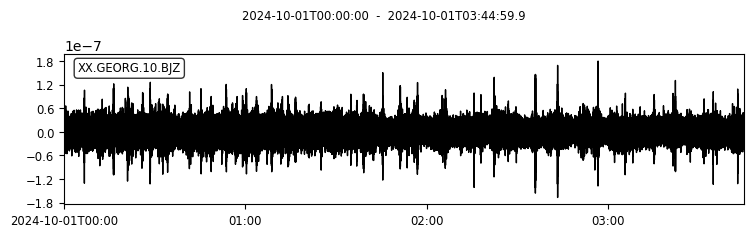

In [5]:
st.plot();

In [6]:
f, p = __welch_psd(st[0].data, st[0].stats.delta, twin_sec=3600)

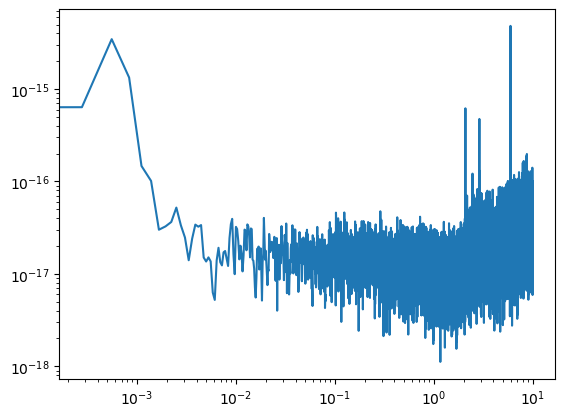

In [7]:
plt.loglog(f, p)

In [10]:
inv_georg = obs.read_inventory(workdir+"/kilauea-data/stationxml_ringlaser/station_BW_GEORG.xml")

In [11]:
from obspy.signal import PPSD

for tr in st:
    ppsd = PPSD(tr.stats, metadata=inv_georg)
    ppsd.add(tr)
    ppsd.plot()

/home/andbro/anaconda3/envs/obs2/lib/python3.10/site-packages/obspy/signal/spectral_estimation.py:979: UserWarning: Error getting response from provided metadata:
Exception: No matching response information found.
Skipping time segment(s).
  warnings.warn(msg)


Exception: No data accumulated